In [3]:
"""
Introducción al análisis basado en regiones

Objetivo
Presentar el análisis basado en regiones como un método clásico de visión artificial para identificar y medir regiones coherentes en imágenes.

Importancia
Hasta ahora, hemos estudiado métodos basados en bordes y descriptores de textura. Sin embargo, muchas tareas de procesamiento de imágenes científicas requieren identificar regiones conectadas y cuantificar sus propiedades.

El análisis basado en regiones constituye un puente natural entre el análisis de texturas y la segmentación.

Relevancia en el procesamiento de imágenes científicas
Los métodos basados en regiones son útiles en:
- Análisis de porosidad
- Detección de partículas
- Caracterización de defectos
- Análisis de fases de materiales
- Conjuntos de datos de tomografía y micro-CT
"""

'\nIntroducción al análisis basado en regiones\n\nObjetivo\nPresentar el análisis basado en regiones como un método clásico de visión artificial para identificar y medir regiones coherentes en imágenes.\n\nImportancia\nHasta ahora, hemos estudiado métodos basados en bordes y descriptores de textura. Sin embargo, muchas tareas de procesamiento de imágenes científicas requieren identificar regiones conectadas y cuantificar sus propiedades.\n\nEl análisis basado en regiones constituye un puente natural entre el análisis de texturas y la segmentación.\n\nRelevancia en el procesamiento de imágenes científicas\nLos métodos basados en regiones son útiles en:\n- Análisis de porosidad\n- Detección de partículas\n- Caracterización de defectos\n- Análisis de fases de materiales\n- Conjuntos de datos de tomografía y micro-CT\n'

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.ndimage import uniform_filter
from skimage import measure, morphology
from skimage.filters import threshold_otsu
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [5]:
np.random.seed(42)
def show_images(images, titles, cmap='gray', figsize=(14, 8), save_path=None):
    n = len(images)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    
    for ax in axes[len(images):]:
        ax.axis('off')
    
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def local_variance(image, size=7):
    image = image.astype(np.float32)
    mean = uniform_filter(image, size=size)
    mean_sq = uniform_filter(image**2, size=size)
    return mean_sq - mean**2


def generate_synthetic_region_image(size=256, n_disks=12):
    image = np.zeros((size, size), dtype=np.float32)
    
    yy, xx = np.indices(image.shape)
    
    for _ in range(n_disks):
        r = np.random.randint(10, 25)
        cy = np.random.randint(r, size - r)
        cx = np.random.randint(r, size - r)
        
        mask = (xx - cx)**2 + (yy - cy)**2 <= r**2
        intensity = np.random.uniform(0.6, 1.0)
        image[mask] = intensity
    
    image += 0.15 * np.random.rand(size, size)
    image = np.clip(image, 0, 1)
    
    return image


def overlay_regions(image, labeled_image):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap='gray')
    ax.imshow(labeled_image, cmap='nipy_spectral', alpha=0.45)
    ax.set_title("Region Overlay")
    ax.axis('off')
    plt.tight_layout()
    return fig


def regionprops_table_df(labeled_image, intensity_image=None):
    props = measure.regionprops_table(
        labeled_image,
        intensity_image=intensity_image,
        properties=[
            'label',
            'area',
            'perimeter',
            'eccentricity',
            'solidity',
            'bbox',
            'centroid',
            'mean_intensity'
        ]
    )
    return pd.DataFrame(props)

In [6]:
"""
Ejemplo sintético inspirado en una imagen científica

Para introducir el análisis basado en regiones, primero creamos una imagen sintética que contiene objetos brillantes incrustados en un fondo más oscuro.
Esta configuración simplificada simula situaciones en las que una imagen científica contiene:
- poros
- partículas
- inclusiones
- defectos
- fases brillantes o densas
"""

'\nEjemplo sintético inspirado en una imagen científica\n\nPara introducir el análisis basado en regiones, primero creamos una imagen sintética que contiene objetos brillantes incrustados en un fondo más oscuro.\nEsta configuración simplificada simula situaciones en las que una imagen científica contiene:\n- poros\n- partículas\n- inclusiones\n- defectos\n- fases brillantes o densas\n'

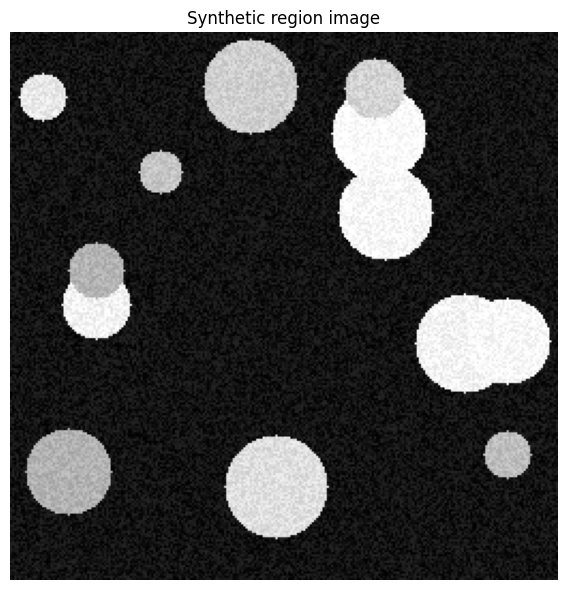

In [9]:
synthetic_image = generate_synthetic_region_image(size=256, n_disks=14)

show_images(
    [synthetic_image],
    ["Synthetic region image"],
    figsize=(6, 6),
    save_path="../figures/figures_region_based/synthetic_region_image.png"
)

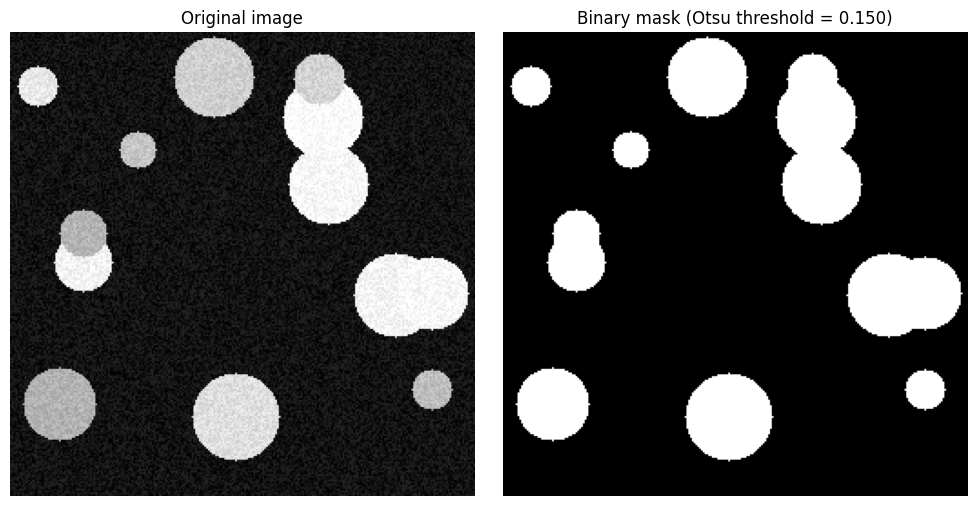

In [10]:
threshold_value = threshold_otsu(synthetic_image)
binary_mask = synthetic_image > threshold_value

show_images(
    [synthetic_image, binary_mask],
    [f"Original image", f"Binary mask (Otsu threshold = {threshold_value:.3f})"],
    figsize=(10, 5),
    save_path="../figures/figures_region_based/otsu_binary_mask.png"
)

In [11]:
"""
Limpieza morfológica

Las máscaras binarias reales suelen contener:
- pequeñas partículas de ruido
- diminutos agujeros
- fragmentos desconectados
Las operaciones morfológicas ayudan a limpiar la máscara antes del análisis de regiones.
"""

'\nLimpieza morfológica\n\nLas máscaras binarias reales suelen contener:\n- pequeñas partículas de ruido\n- diminutos agujeros\n- fragmentos desconectados\nLas operaciones morfológicas ayudan a limpiar la máscara antes del análisis de regiones.\n'

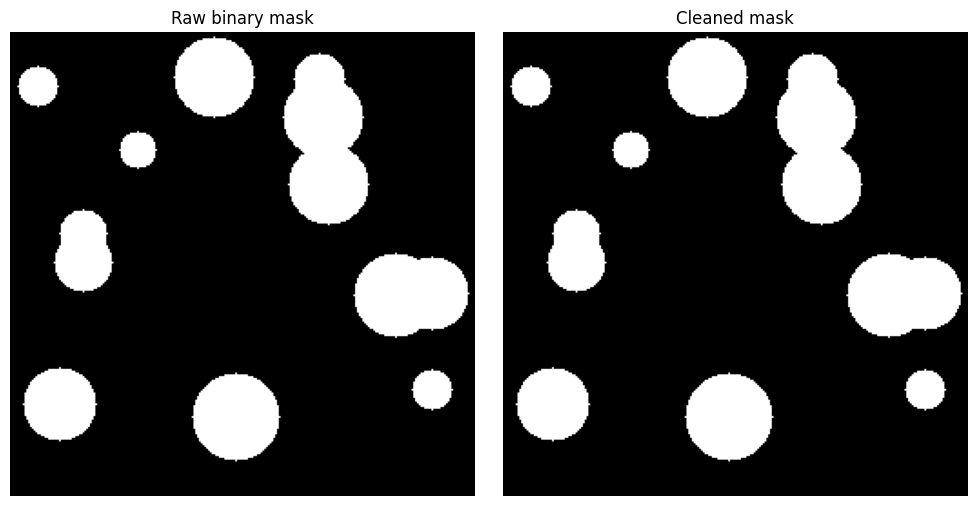

In [13]:
clean_mask = morphology.remove_small_objects(binary_mask, max_size=79)
clean_mask = morphology.remove_small_holes(clean_mask, max_size=79)

show_images(
    [binary_mask, clean_mask],
    ["Raw binary mask", "Cleaned mask"],
    figsize=(10, 5),
    #save_path="../figures/figures_region_based/mask_cleanup.png"
)